# Keras Training on Vertex AI (Aligned to Feature Engineering)
---
##### IMPORTANT NOTE: Managed Vertex AI training is handled in 04_vertex_ai_managed_training.ipynb

Scope:
- Validate environment + permissions
- Load processed dataset from DATA_PREP_PREFIX
- Train a minimal Keras classifier
- Evaluate: Accuracy, ROC-AUC, Confusion Matrix
    - Optional: ROC curve + threshold tuning
- Save model locally (gitignored)
- Optional: save to GCS (TRAINING_PREFIX)
- Keep complexity minimal and portfolio-ready

Non-goals:

- Managed Vertex jobs

- Hyperparameter tuning

- Pipelines

- Packaging

## Imports & Configuration

In [23]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

pd = pd  # silence linters

## Load Project Secrets (Single Source of Truth)

In [24]:
from google.colab import userdata

PROJECT_ID = userdata.get("GCP_PROJECT_ID")
GCS_BUCKET = userdata.get("GCS_BUCKET")
DATA_PREP_PREFIX = userdata.get("DATA_PREP_PREFIX")
TRAINING_PREFIX = userdata.get("TRAINING_PREFIX")
MLOPS_PREFIX = userdata.get("MLOPS_PREFIX")
DEPLOYMENT_PREFIX = userdata.get("DEPLOYMENT_PREFIX")
REGION = userdata.get("REGION")
REPO_NAME = userdata.get("REPO_NAME")
GITHUB_USER = userdata.get("GITHUB_USER")

required_env = {
    "PROJECT_ID": PROJECT_ID,
    "GCS_BUCKET": GCS_BUCKET,
    "DATA_PREP_PREFIX": DATA_PREP_PREFIX,
    "TRAINING_PREFIX": TRAINING_PREFIX,
    "REGION": REGION,
}

missing = [k for k, v in required_env.items() if not v]
if missing:
    raise EnvironmentError(f"Missing required environment variables: {missing}")
print("Environment configuration complete.")



Environment configuration complete.


## Authenticate & Configure gcloud

In [25]:
"""
Authentication (Required for GCS access in Colab)
ensures Colab has GCS access
"""
from google.colab import auth
auth.authenticate_user(project_id=PROJECT_ID)

## Initialize Vertex AI SDK

In [26]:
# This validates IAM + platform wiring.
from google.cloud import aiplatform

aiplatform.init(
    project=PROJECT_ID,
    location=REGION,
    staging_bucket=GCS_BUCKET
)

## Load Processed Dataset from DATA_PREP_PREFIX -- REMOVE?

In [27]:
# --- Load Processed Dataset from DATA_PREP_PREFIX ---
DATA_URI = f"{DATA_PREP_PREFIX.rstrip('/')}/train_processed.csv"
print("Loading dataset from:", DATA_URI)

df = pd.read_csv(DATA_URI)
print("Dataset shape:", df.shape)
df.head()


Loading dataset from: gs://ml-cert-sandbox-bucket-js-001/data-prep/train_processed.csv
Dataset shape: (891, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
0,0,3,0,22.0,1,0,2.110213,2
1,1,1,1,38.0,1,0,4.280593,2
2,1,3,1,26.0,0,0,2.188856,1
3,1,1,1,35.0,1,0,3.990834,2
4,0,3,0,35.0,0,0,2.202765,1


## Train / Validation Split


- Target column = Survived

- All other columns numeric and ready

In [28]:
TARGET = "Survived"
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (712, 7)
Validation shape: (179, 7)


## Build Minimal Keras Model

In [29]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

## Training




In [30]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4674 - loss: 0.8401 - val_accuracy: 0.6145 - val_loss: 0.6953
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6233 - loss: 0.7013 - val_accuracy: 0.6145 - val_loss: 0.6780
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6593 - loss: 0.6700 - val_accuracy: 0.6425 - val_loss: 0.6532
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6405 - loss: 0.6605 - val_accuracy: 0.6313 - val_loss: 0.6233
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6952 - loss: 0.5996 - val_accuracy: 0.7207 - val_loss: 0.6028
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7215 - loss: 0.5931 - val_accuracy: 0.6816 - val_loss: 0.5841
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7246 - loss: 0.5743 - val_accuracy: 0.7430 - val_loss: 0.5632
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7636 - loss: 0.5528 - val_accuracy: 0.7430 - val_loss

## Evaluation (Portfolio-Grade Metrics)
### Preditions

In [31]:
y_pred_proba = model.predict(X_val).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


### Accuracy

In [32]:
val_accuracy = accuracy_score(y_val, y_pred)
print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.7877094972067039


### ROC-AUC

In [33]:
val_roc_auc = roc_auc_score(y_val, y_pred_proba)
print("Validation ROC-AUC:", val_roc_auc)

Validation ROC-AUC: 0.8632411067193676


### Confusion Matrix

In [34]:
cm = confusion_matrix(y_val, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nFormat:")
print("[[TN FP]")
print(" [FN TP]]")

Confusion Matrix:
[[106   4]
 [ 34  35]]

Format:
[[TN FP]
 [FN TP]]


### ROC Curve Visualization

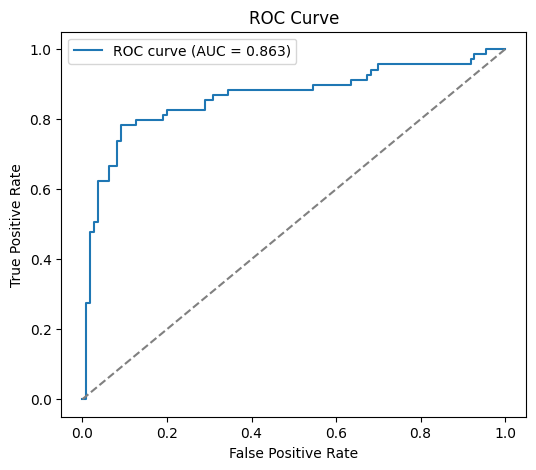

In [35]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {val_roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### Threshold Tuning Analysis

This shows:

- Whether 0.5 is optimal

- Whether recall-heavy thresholds perform better

- If class imbalance affects decision boundary

In [36]:
# Threshold Analysis (brief)
threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "FPR": fpr,
    "TPR": tpr
})
threshold_table.head(10)


,threshold,FPR,TPR
0,inf,0.000000,0.000000
1,0.967971,0.009091,0.000000
2,0.698575,0.009091,0.275362
3,0.690977,0.018182,0.275362
4,0.557171,0.018182,0.478261
5,0.525255,0.027273,0.478261
6,0.520776,0.027273,0.507246
7,0.504461,0.036364,0.507246
8,0.457107,0.036364,0.579710
9,0.453753,0.036364,0.608696


## Save Model Artifact Locally (Gitignored)

In [37]:
LOCAL_ARTIFACT_DIR = Path("../artifacts/training")
LOCAL_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_MODEL_PATH = LOCAL_ARTIFACT_DIR / "model.keras"
model.save(LOCAL_MODEL_PATH)

print("Model saved locally at:", LOCAL_MODEL_PATH)
print("GCS save skipped; enable if IAM/authenticated.")

Model saved locally at: ../artifacts/training/model.keras
GCS save skipped; enable if IAM/authenticated.


## Optional: Save to GCS (Prefix-Aligned)

Commented for safety unless IAM enabled. Only enable when authenticated.

In [38]:
# Optional: Save to GCS (Prefix-Aligned)
GCS_MODEL_URI = f"{TRAINING_PREFIX.rstrip('/')}/model.keras"
model.save(GCS_MODEL_URI)
print("Model saved to:", GCS_MODEL_URI)

Model saved to: gs://ml-cert-sandbox-bucket-js-001/training/model.keras


### Notes / Portfolio Best Practices

1. Ensure `auth.authenticate_user()` is run before GCS operations.

2. Ensure this is run after the local save (LOCAL_MODEL_PATH) completes.

3. `DATA_PREP_PREFIX` drives bucket/folder structure; no hardcoding needed.

4. Local artifact save is authoritative for iterative runs.

5. Downstream notebooks can read dataset directly from `DATA_PREP_PREFIX/train_processed.csv`.

6. ROC curve + threshold table provide visual & numerical evaluation for portfolio-quality metrics.

7. Optional GCS save demonstrates prefix-aligned workflow and mirrors Vertex AI artifact output.

8. This is safe to rerun; it will overwrite any existing object at that URI.

9. This is portfolio-grade as it mirrors how Vertex jobs output artifacts.